In [1]:
import pandas as pd
import openpyxl
import os
import glob, re
import matplotlib.pyplot as plt
import functions as f

In [2]:
path = "model_Fe_Si_B_260311/**/test_res/*_test.xlsx"
files = glob.glob(path, recursive=True)

In [3]:
df = f.read_excel(files, 'errors')
df = df[['id', 'epochs']+[c for c in df.columns if c not in ['id', 'epochs']]]
df

,id,epochs,error,rmse,mae,r2,model
0,scmace_nofe8b4,100,test_energy,182.857256,111.988795,0.768530,model_rnd_e_scmace_nofe8b4_lr0.0001_100_10_test
1,scmace_nofe8b4,100,train_energy,152.843047,87.474704,0.826808,model_rnd_e_scmace_nofe8b4_lr0.0001_100_10_test
2,scmace_nofe8b4,100,test_force,481.067536,273.399745,0.970672,model_rnd_e_scmace_nofe8b4_lr0.0001_100_10_test
3,scmace_nofe8b4,100,train_force,359.272682,271.715308,0.983527,model_rnd_e_scmace_nofe8b4_lr0.0001_100_10_test
4,scmace,100,test_energy,210.180375,124.774518,0.760373,model_rnd_e_scmace_lr0.0001_100_10_test
...,...,...,...,...,...,...,...
571,scmace,40,train_force,484.112120,337.015408,0.969717,model_rnd_e_scmace_lr0.0001_40_10_test
572,scmace_nofe8b4,90,test_energy,188.963887,116.325404,0.752811,model_rnd_e_scmace_nofe8b4_lr0.0001_90_10_test
573,scmace_nofe8b4,90,train_energy,158.415401,90.712991,0.813950,model_rnd_e_scmace_nofe8b4_lr0.0001_90_10_test
574,scmace_nofe8b4,90,test_force,508.495849,287.577999,0.967233,model_rnd_e_scmace_nofe8b4_lr0.0001_90_10_test


In [4]:
#voy a generar un dataframe para cada modelo
scmace = df.query('id == "scmace"')
#matpes = df.query('id == "matpes"')
matpes = df.query('id == "matpes" & epochs != [500, 150]') #esto es ahorita que no quiero ver el de 500 epochs
scmace_nofe8b4 = df.query('id == "scmace_nofe8b4"')
matpes_nofe8b4 = df.query('id == "matpes_nofe8b4"')
#matpes_nofe8b4_freeze = df.query('id == "matpes_nofe8b4_freeze"')
matpes_nofe8b4_freeze4 = df.query('id == "matpes_nofe8b4_freeze_4"')
matpes_nofe8b4_freeze6 = df.query('id == "matpes_nofe8b4_freeze_6"')


MAE and RMSE for energy

In [5]:
#f.plot_global_error([scmace, scmace_nofe8b4, matpes, matpes_nofe8b4], ['mae'], ['scmace', 'scmace_nofe8b4', 'matpes', 'matpes_nofe8b4'], ['Test data', 'Train data'], 'energy')

In [6]:
#f.plot_global_error([scmace, scmace_nofe8b4, matpes, matpes_nofe8b4], ['mae'], ['scmace', 'scmace_nofe8b4', 'matpes', 'matpes_nofe8b4'], ['Test data', 'Train data'], 'force')

In [7]:
#f.plot_global_error([scmace, scmace_nofe8b4, matpes, matpes_nofe8b4], ['rmse'], ['scmace', 'scmace_nofe8b4', 'matpes', 'matpes_nofe8b4'], ['Test data', 'Train data'], 'force')

In [8]:
#f.plot_global_error([scmace, scmace_nofe8b4], ['mae', 'rmse'], ['scmace', 'scmace_nofe8b4'], ['Test data', 'Train data'], 'energy')

In [9]:
#f.plot_global_error([scmace, scmace_nofe8b4], ['mae', 'rmse'], ['scmace', 'scmace_nofe8b4'], ['Test data', 'Train data'], 'force')

In [10]:
#f.plot_global_error([matpes, matpes_nofe8b4], ['mae', 'rmse'], ['matpes', 'matpes_nofe8b4'], ['Test data', 'Train data'], 'energy')

Comparison between fine tuning and freeze tuning

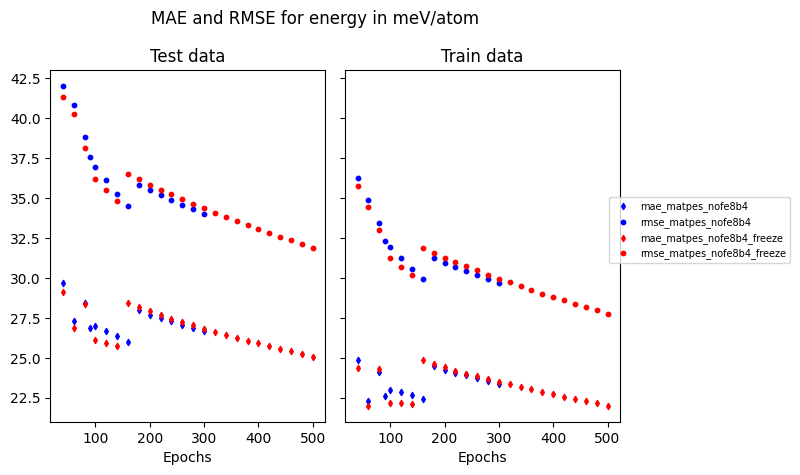

In [11]:
f.plot_global_error([matpes_nofe8b4, matpes_nofe8b4_freeze4], ['mae', 'rmse'], ['matpes_nofe8b4', 'matpes_nofe8b4_freeze'], ['Test data', 'Train data'], 'energy')

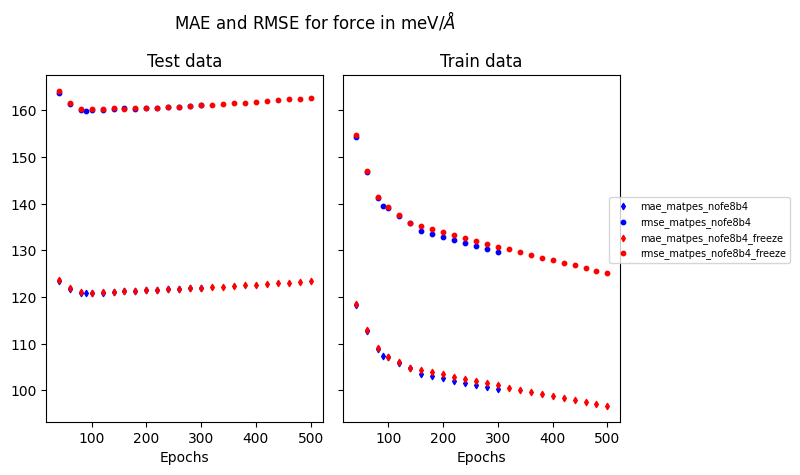

In [12]:
f.plot_global_error([matpes_nofe8b4, matpes_nofe8b4_freeze4], ['mae', 'rmse'], ['matpes_nofe8b4', 'matpes_nofe8b4_freeze'], ['Test data', 'Train data'], 'force')

In [13]:
#matpes_nofe8b4_freeze6

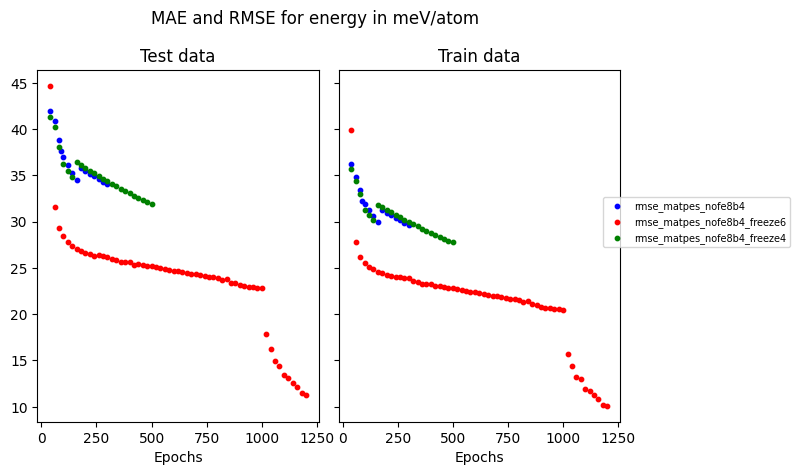

In [14]:
error_type = ['rmse']
value = 'energy'
models = [matpes_nofe8b4, matpes_nofe8b4_freeze6, matpes_nofe8b4_freeze4]
f.plot_global_error(models, error_type, ['matpes_nofe8b4', 'matpes_nofe8b4_freeze6', 'matpes_nofe8b4_freeze4'], ['Test data', 'Train data'], value)

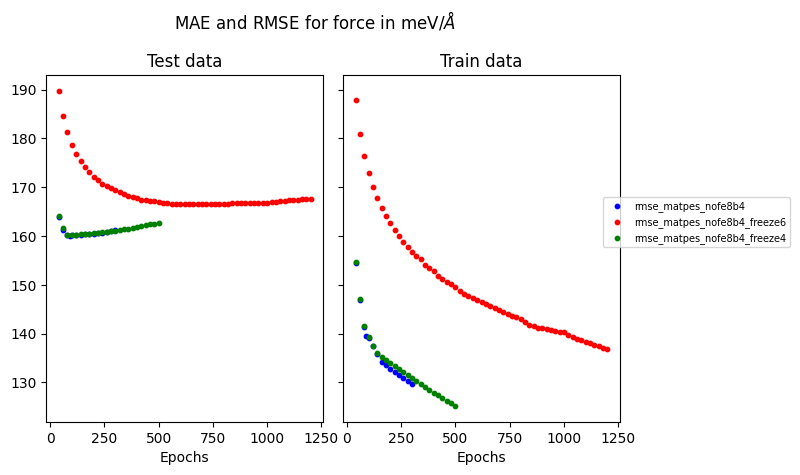

In [15]:
error_type = ['rmse']
value = 'force'
models = [matpes_nofe8b4, matpes_nofe8b4_freeze6, matpes_nofe8b4_freeze4]
f.plot_global_error(models, error_type, ['matpes_nofe8b4', 'matpes_nofe8b4_freeze6', 'matpes_nofe8b4_freeze4'], ['Test data', 'Train data'], value)

In [16]:
#err_comparison = pd.concat([matpes_nofe8b4.query('epochs == 80'),matpes_nofe8b4_freeze.query('epochs == 80')])
err_comparison = pd.concat([matpes_nofe8b4, matpes_nofe8b4_freeze4, matpes_nofe8b4_freeze6])
#err_comparison = err_comparison.drop(columns=['epochs'])
#err_comparison

In [17]:
#err_comparison.query('error == ["test_energy","train_energy"]')
err_comparison.query('error == "train_energy"').sort_values('rmse', ascending=True)

,id,epochs,error,rmse,mae,r2,model
197,matpes_nofe8b4_freeze_6,1200,train_energy,10.098659,7.756370,0.999244,model_rnd_e_matpes_nofe8b4_freeze_6_lr0.0001_1...
161,matpes_nofe8b4_freeze_6,1180,train_energy,10.156563,7.405334,0.999235,model_rnd_e_matpes_nofe8b4_freeze_6_lr0.0001_1...
493,matpes_nofe8b4_freeze_6,1160,train_energy,10.879836,8.365942,0.999122,model_rnd_e_matpes_nofe8b4_freeze_6_lr0.0001_1...
301,matpes_nofe8b4_freeze_6,1140,train_energy,11.282865,8.680605,0.999056,model_rnd_e_matpes_nofe8b4_freeze_6_lr0.0001_1...
373,matpes_nofe8b4_freeze_6,1120,train_energy,11.725738,9.026806,0.998981,model_rnd_e_matpes_nofe8b4_freeze_6_lr0.0001_1...
...,...,...,...,...,...,...,...
537,matpes_nofe8b4_freeze_4,60,train_energy,34.408410,21.990468,0.991223,model_rnd_e_matpes_nofe8b4_freeze_4_lr0.0001_6...
121,matpes_nofe8b4,60,train_energy,34.862336,22.270564,0.990990,model_rnd_e_matpes_nofe8b4_lr0.0001_60_10_test
361,matpes_nofe8b4_freeze_4,40,train_energy,35.712658,24.345129,0.990545,model_rnd_e_matpes_nofe8b4_freeze_4_lr0.0001_4...
45,matpes_nofe8b4,40,train_energy,36.272503,24.822747,0.990246,model_rnd_e_matpes_nofe8b4_lr0.0001_40_10_test


In [18]:
err_comparison.query('error == "test_energy"').sort_values('rmse', ascending=True)

,id,epochs,error,rmse,mae,r2,model
196,matpes_nofe8b4_freeze_6,1200,test_energy,11.223382,8.591031,0.999128,model_rnd_e_matpes_nofe8b4_freeze_6_lr0.0001_1...
160,matpes_nofe8b4_freeze_6,1180,test_energy,11.433401,8.341296,0.999095,model_rnd_e_matpes_nofe8b4_freeze_6_lr0.0001_1...
492,matpes_nofe8b4_freeze_6,1160,test_energy,12.109075,9.299966,0.998985,model_rnd_e_matpes_nofe8b4_freeze_6_lr0.0001_1...
300,matpes_nofe8b4_freeze_6,1140,test_energy,12.565855,9.665892,0.998907,model_rnd_e_matpes_nofe8b4_freeze_6_lr0.0001_1...
372,matpes_nofe8b4_freeze_6,1120,test_energy,13.067676,10.067227,0.998818,model_rnd_e_matpes_nofe8b4_freeze_6_lr0.0001_1...
...,...,...,...,...,...,...,...
536,matpes_nofe8b4_freeze_4,60,test_energy,40.268501,26.873674,0.988775,model_rnd_e_matpes_nofe8b4_freeze_4_lr0.0001_6...
120,matpes_nofe8b4,60,test_energy,40.839759,27.266421,0.988454,model_rnd_e_matpes_nofe8b4_lr0.0001_60_10_test
360,matpes_nofe8b4_freeze_4,40,test_energy,41.333911,29.096374,0.988173,model_rnd_e_matpes_nofe8b4_freeze_4_lr0.0001_4...
44,matpes_nofe8b4,40,test_energy,41.982686,29.652715,0.987799,model_rnd_e_matpes_nofe8b4_lr0.0001_40_10_test


In [19]:
err_comparison.query('error == ["test_force","train_force"]')

,id,epochs,error,rmse,mae,r2,model
14,matpes_nofe8b4,220,test_force,160.571648,121.569571,0.996733,model_rnd_e_matpes_nofe8b4_lr0.0001_220_10_test
15,matpes_nofe8b4,220,train_force,132.189518,102.116622,0.997770,model_rnd_e_matpes_nofe8b4_lr0.0001_220_10_test
18,matpes_nofe8b4,80,test_force,160.120801,120.835291,0.996751,model_rnd_e_matpes_nofe8b4_lr0.0001_80_10_test
19,matpes_nofe8b4,80,train_force,141.337187,108.850125,0.997451,model_rnd_e_matpes_nofe8b4_lr0.0001_80_10_test
26,matpes_nofe8b4,240,test_force,160.698383,121.681674,0.996727,model_rnd_e_matpes_nofe8b4_lr0.0001_240_10_test
...,...,...,...,...,...,...,...
543,matpes_nofe8b4_freeze_6,740,train_force,144.010944,111.012072,0.997353,model_rnd_e_matpes_nofe8b4_freeze_6_lr0.0001_7...
546,matpes_nofe8b4_freeze_6,80,test_force,181.224955,136.758354,0.995838,model_rnd_e_matpes_nofe8b4_freeze_6_lr0.0001_8...
547,matpes_nofe8b4_freeze_6,80,train_force,176.314756,134.648362,0.996033,model_rnd_e_matpes_nofe8b4_freeze_6_lr0.0001_8...
558,matpes_nofe8b4_freeze_6,880,test_force,166.729033,126.520710,0.996477,model_rnd_e_matpes_nofe8b4_freeze_6_lr0.0001_8...


In [20]:
#matpes.query('error == ["test_energy"]').sort_values('epochs', ascending=True)

In [21]:
print(f.min(scmace, 'mae'), f.min(matpes, 'mae'))

                                                model         mae
error                                                            
test_energy   model_rnd_e_scmace_lr0.0001_100_10_test  124.774518
test_force    model_rnd_e_scmace_lr0.0001_100_10_test  266.765534
train_energy  model_rnd_e_scmace_lr0.0001_100_10_test  104.387671
train_force   model_rnd_e_scmace_lr0.0001_100_10_test  264.249749                                                 model        mae
error                                                           
test_energy   model_rnd_e_matpes_lr0.0001_100_10_test  24.019415
test_force    model_rnd_e_matpes_lr0.0001_100_10_test   0.119892
train_energy  model_rnd_e_matpes_lr0.0001_100_10_test  23.863738
train_force   model_rnd_e_matpes_lr0.0001_100_10_test   0.105124


Reading the config errors

In [29]:
df_config =f.read_excel(files, 'config_errors')
#df_config
df_config = df_config[['id', 'epochs', 'config', 'n_configs', 'mae', 'rmse', 'error', 'model']]
#df_config

In [30]:
df_config.query('id == "matpes" & epochs == 100')

,id,epochs,config,n_configs,mae,rmse,error,model
134,matpes,100,Fe12B3Si3,48,72.772737,73.184691,test_energy,model_rnd_e_matpes_lr0.0001_100_10_test
135,matpes,100,Fe12Si4,12,9.839741,10.007741,test_energy,model_rnd_e_matpes_lr0.0001_100_10_test
136,matpes,100,Fe16,11,6.880569,7.642087,test_energy,model_rnd_e_matpes_lr0.0001_100_10_test
137,matpes,100,Fe34B10Si10,133,3.642926,4.661568,test_energy,model_rnd_e_matpes_lr0.0001_100_10_test
138,matpes,100,Fe8B4,8,115.094036,115.104171,test_energy,model_rnd_e_matpes_lr0.0001_100_10_test
139,matpes,100,Fe12B3Si3,132,72.800135,73.055497,train_energy,model_rnd_e_matpes_lr0.0001_100_10_test
140,matpes,100,Fe12Si4,39,9.987663,10.192224,train_energy,model_rnd_e_matpes_lr0.0001_100_10_test
141,matpes,100,Fe16,40,8.827048,10.186386,train_energy,model_rnd_e_matpes_lr0.0001_100_10_test
142,matpes,100,Fe34B10Si10,590,3.656830,4.759407,train_energy,model_rnd_e_matpes_lr0.0001_100_10_test
143,matpes,100,Fe8B4,44,173.979772,419.412618,train_energy,model_rnd_e_matpes_lr0.0001_100_10_test


In [31]:
df.query('id == "matpes" & epochs == 100')

,id,epochs,error,rmse,mae,r2,model
64,matpes,100,test_energy,41.652997,24.019415,0.990589,model_rnd_e_matpes_lr0.0001_100_10_test
65,matpes,100,train_energy,100.094452,23.863738,0.951146,model_rnd_e_matpes_lr0.0001_100_10_test
66,matpes,100,test_force,0.159079,0.119892,0.996762,model_rnd_e_matpes_lr0.0001_100_10_test
67,matpes,100,train_force,0.136716,0.105124,0.997585,model_rnd_e_matpes_lr0.0001_100_10_test


In [32]:
#voy a generar un dataframe para cada modelo
scmace_config = df_config.query('id == "scmace"')
#matpes_config = df_config.query('id == "matpes"')
matpes_config = df_config.query('id == "matpes" & epochs != [500, 150]')
scmace_nofe8b4_config = df_config.query('id == "scmace_nofe8b4"')
matpes_nofe8b4_config = df_config.query('id == "matpes_nofe8b4"')

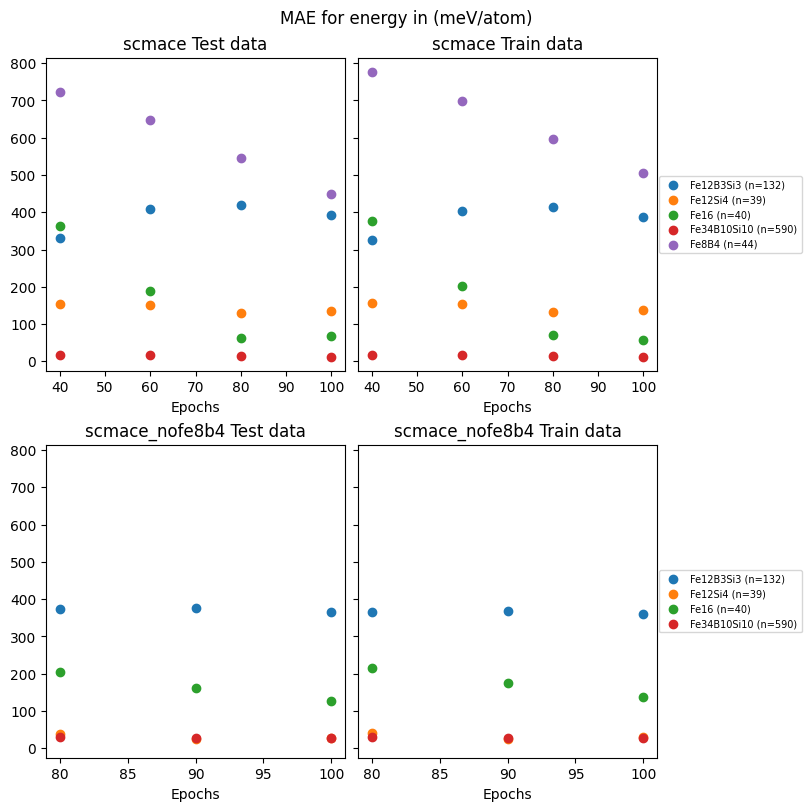

In [33]:
f.plot_config_error([scmace_config, scmace_nofe8b4_config], 'mae', ['Test data', 'Train data'], 'MAE', ['scmace', 'scmace_nofe8b4'], 'energy')

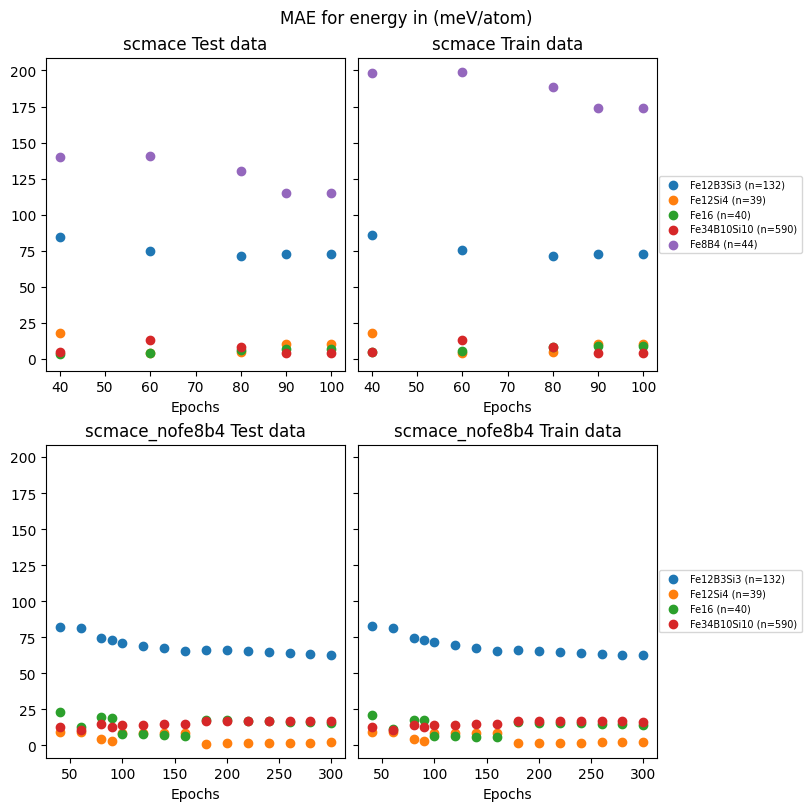

In [34]:
f.plot_config_error([matpes_config, matpes_nofe8b4_config], 'mae', ['Test data', 'Train data'], 'MAE', ['scmace', 'scmace_nofe8b4'], 'energy')